# Telco Customer Churn — Exploratory Data Analysis

Antes de entrenar nada, entendemos el dataset:
- ¿Qué features tenemos?
- ¿Está balanceado el target?
- ¿Hay missing values?
- ¿Qué correlaciona con el churn?

In [8]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.max_columns', None)

In [9]:
df = pd.read_csv('../data/raw/telco_churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Calidad del dataset

In [10]:
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# TotalCharges llega como string
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nRows with TotalCharges NaN: {df['TotalCharges'].isna().sum()}")

Missing values:
Series([], dtype: int64)

Rows with TotalCharges NaN: 11


## 2. Balance del target

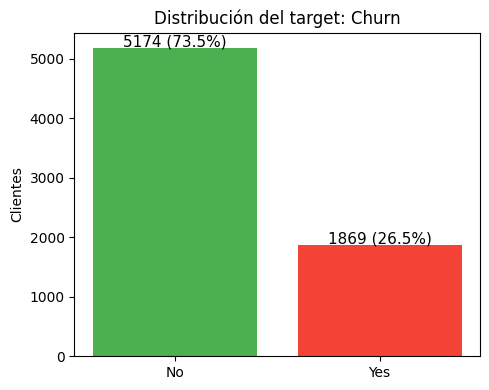

In [11]:
churn_counts = df['Churn'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(churn_counts.index, churn_counts.values, color=['#4CAF50', '#F44336'])
for bar, count in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count} ({count/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Distribución del target: Churn')
ax.set_ylabel('Clientes')
plt.tight_layout()
plt.show()

# El dataset está desbalanceado (~26% churn) — métrica relevante: AUC-ROC y F1

## 3. Distribución de features numéricas

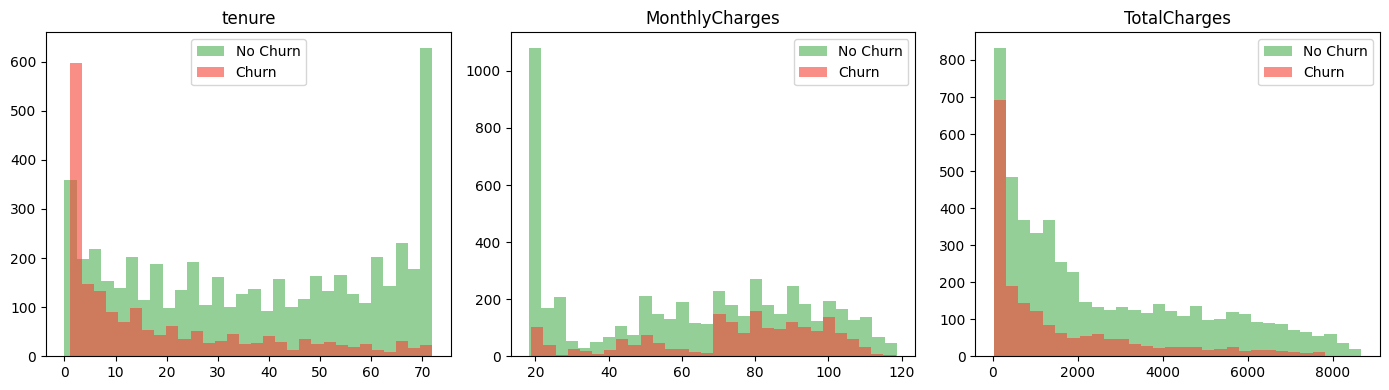

In [12]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, numeric_cols):
    for churn_val, color, label in [('No', '#4CAF50', 'No Churn'), ('Yes', '#F44336', 'Churn')]:
        ax.hist(df[df['Churn'] == churn_val][col].dropna(),
                alpha=0.6, bins=30, color=color, label=label)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

# Observación: clientes con poco tenure hacen más churn → feature importante

## 4. Churn rate por tipo de contrato

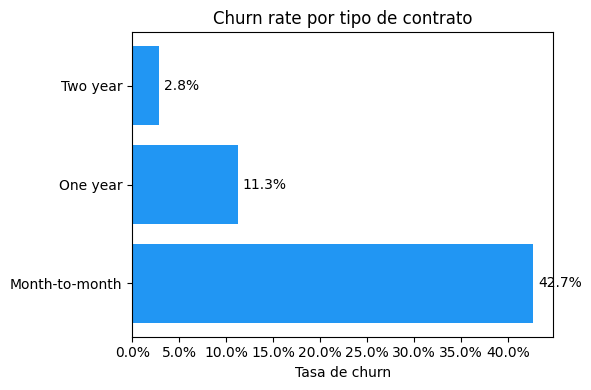

In [13]:
churn_by_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean()
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(churn_by_contract.index, churn_by_contract.values, color='#2196F3')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Churn rate por tipo de contrato')
ax.set_xlabel('Tasa de churn')
for bar, val in zip(bars, churn_by_contract.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center')
plt.tight_layout()
plt.show()

# Month-to-month tiene mucho más churn → 'Contract' será una feature clave

## 5. Features preprocesadas

In [14]:
from data_prep import load_and_clean, encode_features

df_clean = load_and_clean('../data/raw/telco_churn.csv')
df_encoded = encode_features(df_clean)
print(f'Shape tras encoding: {df_encoded.shape}')
print(f'Features: {list(df_encoded.columns)}')

Shape tras encoding: (7032, 24)
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
